# 回帰（Regression） - 住宅価格の予測

カリフォルニア住宅データセットを使って、住宅価格を予測します。

| ステップ | 内容 |
|----------|------|
| 1 | データの読み込み・確認 |
| 2 | 学習用・テスト用に分割 |
| 3 | 前処理（標準化） |
| 4 | モデルの学習 |
| 5 | 予測・評価 |
| 6 | 可視化 |

## 1. データの読み込み・確認

In [1]:
from sklearn.datasets import fetch_california_housing
import pandas as pd

housing = fetch_california_housing()
X = housing.data
y = housing.target  # 住宅価格（単位：$100,000）

df = pd.DataFrame(X, columns=housing.feature_names)
df['Price'] = y
print("データ形状:", X.shape)
df.head(10)

データ形状: (20640, 8)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
5,4.0368,52.0,4.761658,1.103627,413.0,2.139896,37.85,-122.25,2.697
6,3.6591,52.0,4.931907,0.951362,1094.0,2.128405,37.84,-122.25,2.992
7,3.1200,52.0,4.797527,1.061824,1157.0,1.788253,37.84,-122.25,2.414
8,2.0804,42.0,4.294118,1.117647,1206.0,2.026891,37.84,-122.26,2.267
9,3.6912,52.0,4.970588,0.990196,1551.0,2.172269,37.84,-122.25,2.611


In [2]:
# 基本統計量の確認
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


## 2. 学習用・テスト用に分割（8:2）

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("学習データ:", X_train.shape)
print("テストデータ:", X_test.shape)

学習データ: (16512, 8)
テストデータ: (4128, 8)


## 3. 前処理（標準化）

In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

## 4. モデルの学習

**線形回帰（Linear Regression）** を使います。  
特徴量の線形結合で価格を予測するシンプルなモデルです。

In [5]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)
print("学習完了")

学習完了


## 5. 予測・評価

回帰の評価指標:
- **MAE**: 平均絶対誤差（小さいほど良い）
- **RMSE**: 二乗平均平方根誤差（外れ値に敏感）
- **R²**: 決定係数（1.0 に近いほど良い）

In [6]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

y_pred = model.predict(X_test)

print("MAE  :", round(mean_absolute_error(y_test, y_pred), 4))
print("RMSE :", round(root_mean_squared_error(y_test, y_pred), 4))
print("R²   :", round(r2_score(y_test, y_pred), 4))

MAE  : 0.5332
RMSE : 0.7456
R²   : 0.5758


## 6. 可視化

/tmp/ipykernel_15245/413976810.py:22: UserWarning: Glyph 27491 (\N{CJK UNIFIED IDEOGRAPH-6B63}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_15245/413976810.py:22: UserWarning: Glyph 35299 (\N{CJK UNIFIED IDEOGRAPH-89E3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_15245/413976810.py:22: UserWarning: Glyph 20516 (\N{CJK UNIFIED IDEOGRAPH-5024}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_15245/413976810.py:22: UserWarning: Glyph 20104 (\N{CJK UNIFIED IDEOGRAPH-4E88}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_15245/413976810.py:22: UserWarning: Glyph 28204 (\N{CJK UNIFIED IDEOGRAPH-6E2C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_15245/413976810.py:22: UserWarning: Glyph 27531 (\N{CJK UNIFIED IDEOGRAPH-6B8B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_15245/413976810.py:22: UserWarning: Glyph 24046 (\N{CJK UNIFIED IDEOGRAPH-5DEE}

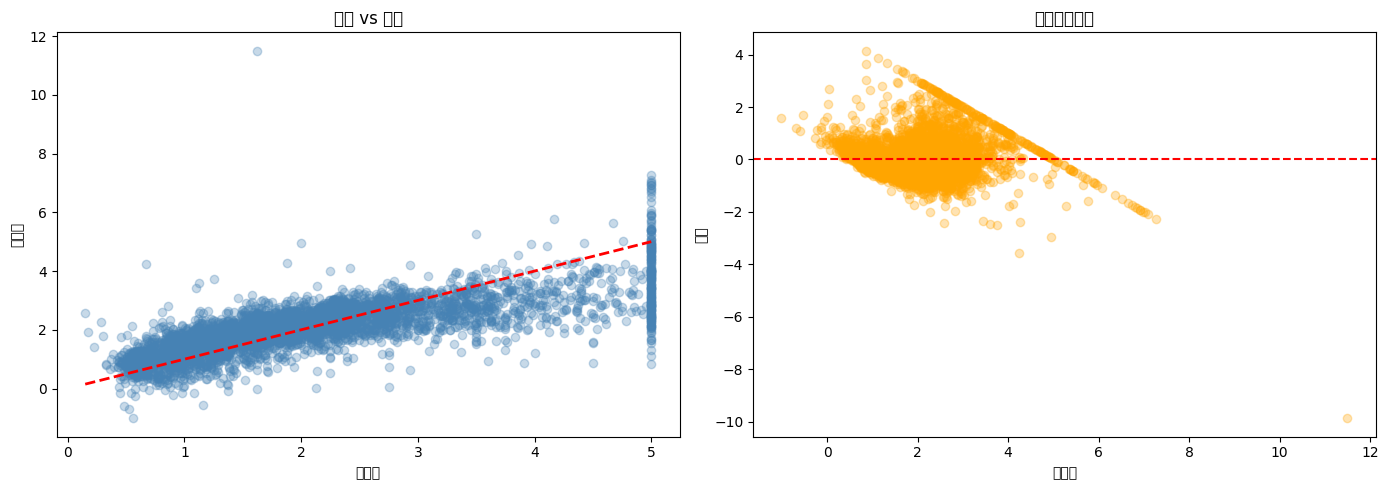

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# --- 6-1. 正解 vs 予測の散布図 ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 散布図
axes[0].scatter(y_test, y_pred, alpha=0.3, color='steelblue')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel("正解値")
axes[0].set_ylabel("予測値")
axes[0].set_title("正解 vs 予測")

# 残差プロット
residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.3, color='orange')
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_xlabel("予測値")
axes[1].set_ylabel("残差")
axes[1].set_title("残差プロット")

plt.tight_layout()
plt.show()

/tmp/ipykernel_15245/3481092288.py:12: UserWarning: Glyph 20418 (\N{CJK UNIFIED IDEOGRAPH-4FC2}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_15245/3481092288.py:12: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_15245/3481092288.py:12: UserWarning: Glyph 29305 (\N{CJK UNIFIED IDEOGRAPH-7279}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_15245/3481092288.py:12: UserWarning: Glyph 24500 (\N{CJK UNIFIED IDEOGRAPH-5FB4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_15245/3481092288.py:12: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_15245/3481092288.py:12: UserWarning: Glyph 12398 (\N{HIRAGANA LETTER NO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_15245/3481092288.py:12: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS})

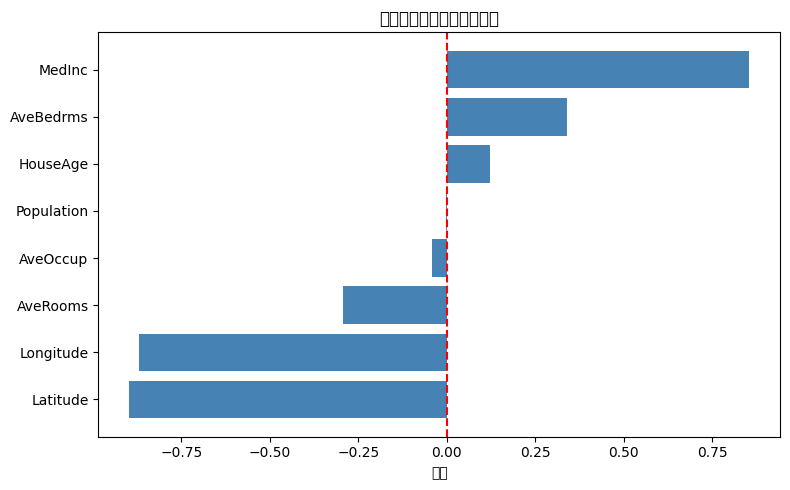

In [8]:
# --- 6-2. 特徴量の重要度（係数）---
coef_df = pd.DataFrame({
    'feature': housing.feature_names,
    'coefficient': model.coef_
}).sort_values('coefficient')

plt.figure(figsize=(8, 5))
plt.barh(coef_df['feature'], coef_df['coefficient'], color='steelblue')
plt.axvline(0, color='red', linestyle='--')
plt.xlabel("係数")
plt.title("特徴量の係数（線形回帰）")
plt.tight_layout()
plt.show()